# Sentiment Analysis Noice App Google Play Store

In [1]:
import pandas as pd
import re
import string
import nltk
import joblib
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\IRUL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\IRUL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\IRUL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Data Loading & Exploratory Data Analysis

In [2]:
df = pd.read_csv('../dataset/noice_app_reviews.csv')

C:\Users\IRUL\AppData\Local\Temp\ipykernel_10716\4116783091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score', data=df, palette='viridis')


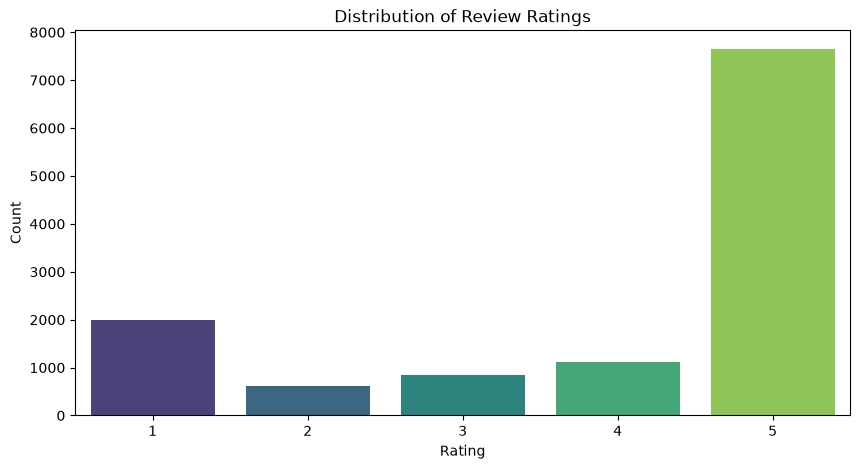

In [3]:
# Visualisasi distribusi rating ulasan
plt.figure(figsize=(10, 5))
sns.countplot(x='score', data=df, palette='viridis')
plt.title('Distribution of Review Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [4]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,43b531f3-1b08-4e19-b36b-662d88aa0b36,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasinya bagus, ada podcast favorit saya, d...",5,1,3.56,2026-06-24 22:36:41,Wohoooo! Senang sekali bisa dapat penilaian da...,2026-06-25 15:31:01,3.56
1,41c8cfd2-a8cc-48ed-992a-4db7627969ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"jujur sebenarnya bagus kok aplikasinya, kita m...",1,5,3.55.1,2026-05-09 01:27:24,"Halo Kak VIKI, makasih banyak buat penilaianny...",2026-05-11 16:39:55,3.55.1
2,d1495c97-f24f-4d15-8c86-369c29b39256,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kecewa sm aplikasinya sudah download tp gak bi...,1,2,3.56,2026-06-05 19:52:56,"Halo Kak Atha, mohon maaf ya atas ketidaknyama...",2026-06-15 00:18:43,3.56
3,f6b7f1ad-46b6-4409-bdd3-6e86089bd4f2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aku naikkan bintangku karena konten Deddy Issu...,4,17,3.56,2026-05-28 10:19:53,"Halo Kak Adi, mohon maaf ya atas ketidaknyaman...",2025-11-04 10:47:46,3.56
4,5335c10b-85e5-4d71-ab56-2c66391a509f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sy download video tapi ternyata yg terdownload...,1,0,3.55.1,2026-06-08 18:50:43,"Halo Kak Ryuka, mohon maaf ya atas ketidaknyam...",2026-06-15 00:18:25,3.55.1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12223 entries, 0 to 12222
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              12223 non-null  str  
 1   userName              12223 non-null  str  
 2   userImage             12223 non-null  str  
 3   content               12223 non-null  str  
 4   score                 12223 non-null  int64
 5   thumbsUpCount         12223 non-null  int64
 6   reviewCreatedVersion  10275 non-null  str  
 7   at                    12223 non-null  str  
 8   replyContent          3594 non-null   str  
 9   repliedAt             3594 non-null   str  
 10  appVersion            10275 non-null  str  
dtypes: int64(2), str(9)
memory usage: 1.0 MB


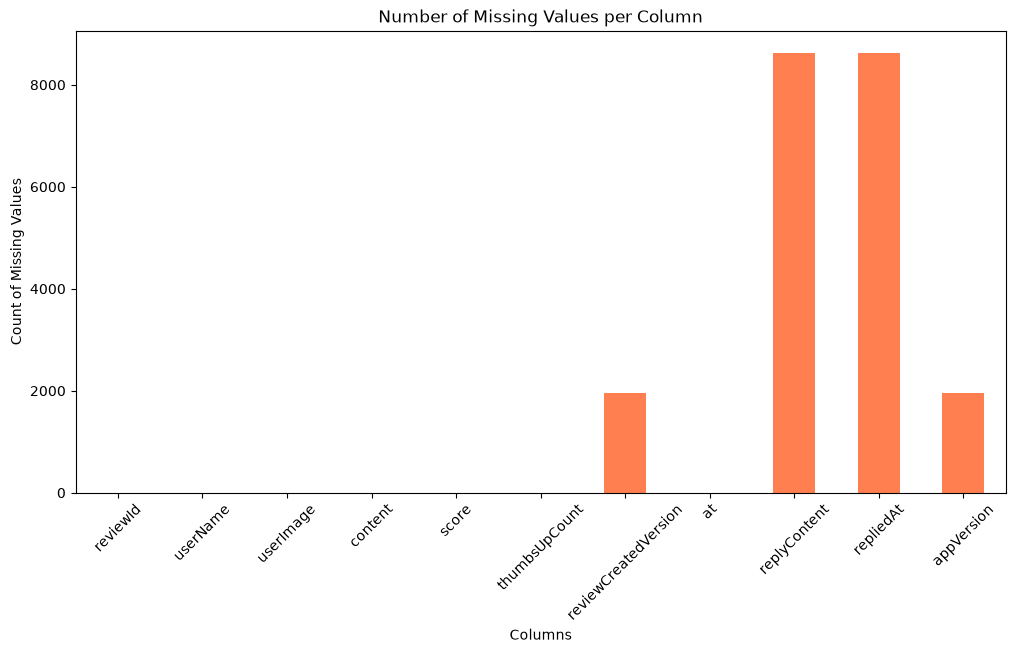

In [6]:
# Visualisasi jumlah nilai yang hilang per kolom
missing_values = df.isna().sum()

plt.figure(figsize=(12, 6))
missing_values.plot(kind='bar', color='coral')
plt.title('Number of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=45)
plt.show()

## Data Cleaning

In [4]:
# Hapus kolom yang memiliki banyak nilai yang hilang
df.drop(['replyContent', 'repliedAt'], axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12223 entries, 0 to 12222
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   reviewId              12223 non-null  str  
 1   userName              12223 non-null  str  
 2   userImage             12223 non-null  str  
 3   content               12223 non-null  str  
 4   score                 12223 non-null  int64
 5   thumbsUpCount         12223 non-null  int64
 6   reviewCreatedVersion  10275 non-null  str  
 7   at                    12223 non-null  str  
 8   appVersion            10275 non-null  str  
dtypes: int64(2), str(7)
memory usage: 3.8 MB


In [5]:
# Imputasi nilai yang hilang
df['reviewCreatedVersion'].fillna('Unknown', inplace=True)
df['appVersion'].fillna('Unknown', inplace=True)

print(df.isna().sum())

reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion    1948
at                         0
appVersion              1948
dtype: int64


C:\Users\IRUL\AppData\Local\Temp\ipykernel_10716\768005342.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['reviewCreatedVersion'].fillna('Unknown', inplace=True)
C:\Users\IRUL\AppData\Local\Temp\ipykernel_10716\768005342.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assi

## Data Preprocessing

In [6]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
 
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text
 
# Mengubah semua karakter dalam teks menjadi huruf kecil
def casefoldingText(text):
    text = text.lower()
    return text
 
# Memecah atau membagi string, teks menjadi daftar token
def tokenizingText(text):
    text = word_tokenize(text)
    return text

# Menghapus stopwords dalam teks
def filteringText(text): 
    listStopwords = set(stopwords.words('indonesian'))
    # Menghapus kata negasi dari daftar stopwords
    negasi = {'tidak', 'bukan', 'belum', 'jangan', 'tak'}
    listStopwords = listStopwords - negasi
    # Menambahkan kata-kata yang tidak relevan ke daftar stopwords
    listStopwords.update(['noice','aplikasi','app','apk','hp','iya','yaa','nya','na','sih','ku',"di","ya","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text
 
# Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    stemmed_text = ' '.join(stemmed_words)
 
    return stemmed_text

# Mengubah daftar kata menjadi kalimat
def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

In [7]:
slangwords = {"@": "di", "apk": "aplikasi", "gua": "saya", "sy": "saya", "td": "tadi", "dikit": "sedikit", "ud": "sudah", "udh": "sudah", "sdh": "sudah", "abis": "habis", "aja": "saja", "masi": "masih", "bgt": "banget", "gak": "tidak", "gk": "gak", "ga": "tidak", 
              "pake": "pakai", "jgn": "jangan", "yg": "yang", "klo": "kalau", "kalo": "kalau", "gmn": "bagaimana", "gitu": "begitu", "dgn": "dengan", "dr": "dari", "sm": "sama", "sbg": "sebagai", "sblm": "sebelum", "knp": "kenapa", "hp": "telepon", "balikin": "kembalikan", 
              "ngga": "tidak", "nggak": "tidak", "nih": "ini", "kmn": "kemana", "mulu": "selalu", "bgtt": "banget", "gw": "saya", "boong": "bohong", "kh": "ya", "gapapa": "tidak apa-apa", "gpp": "tidak apa-apa", "please": "tolong", "plis": "tolong", "pliss": "tolong", 
              "bug": "kesalahan", "bgtu": "begitu", "trs": "terus", "trus": "terus", "play": "dimainkan", "ngulang": "mengulang", "nntn": "menonton", "nonton": "menonton", "dengerin": "mendengarkan", "udah": "sudah", "buat": "untuk", "cuma": "hanya", "pas": "saat", "denger": "mendengar", 
              "karna": "karena", "makin": "semakin", "gabisa": "tidak bisa", "bikin": "membuat", "biar": "agar", "dah": "sudah", "tau": "tahu", "gimana": "bagaimana", "tp": "tapi", "doang": "saja", "pengen": "ingin", "cuman": "hanya", "tetep": "tetap", "gue": "saya", "ni": "ini", 
              "sampe": "sampai", "lemot": "lambat", "muter": "memutar", "kaya": "seperti", "tambahin": "tambahkan", "bener": "benar", "nyesel": "menyesal", "yaa": "ya", "mantab": "mantap", "emang": "memang", "lg": "lagi", "kayak": "seperti", "jd": "jadi", "tpi": "tapi", "gini": "begini",
              "temen": "teman", "mending": "lebih baik", "liat": "melihat", "males": "malas", "mantep": "mantap", "mantul": "mantap", "mantapp": "mantap", "baguss": "bagus", "dapet": "dapat", "jg": "juga", "dlu": "dulu", "makasih": "terima kasih", "krn": "karena", "nemenin": "menemani", 
              "nomer": "nomor", "gokil": "keren", "pdhl": "padahal","ko": "kok", "gabut": "bosan", "lgi": "lagi", "benerin": "perbaiki", "ngelag": "tersendat", "ilang": "hilang", "seneng": "senang", "wkwk": "tertawa", "hehe": "tertawa", "gaada": "tidak ada", "ny": "nya", "nunggu": "menunggu", 
              "ngebug": "kesalahan", "kek": "seperti", "jdi": "jadi", "nyoba": "mencoba", "yah": "ya"
              }
def fix_slangwords(text):
    words = text.split()
    fixed_words = []
 
    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
 
    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [8]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
df['text_clean'] = df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
df['text_casefoldingText'] = df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
df['text_slangwords'] = df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
df['text_tokenizingText'] = df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
df['text_stopword'] = df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_final'
df['text_final'] = df['text_stopword'].apply(toSentence)

In [9]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_final
0,43b531f3-1b08-4e19-b36b-662d88aa0b36,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasinya bagus, ada podcast favorit saya, d...",5,1,3.56,2026-06-24 22:36:41,3.56,aplikasinya bagus ada podcast favorit saya dan...,aplikasinya bagus ada podcast favorit saya dan...,aplikasinya bagus ada podcast favorit saya dan...,"[aplikasinya, bagus, ada, podcast, favorit, sa...","[aplikasinya, bagus, podcast, favorit, fitur, ...",aplikasinya bagus podcast favorit fitur downlo...
1,41c8cfd2-a8cc-48ed-992a-4db7627969ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"jujur sebenarnya bagus kok aplikasinya, kita m...",1,5,3.55.1,2026-05-09 01:27:24,3.55.1,jujur sebenarnya bagus kok aplikasinya kita me...,jujur sebenarnya bagus kok aplikasinya kita me...,jujur sebenarnya bagus kok aplikasinya kita me...,"[jujur, sebenarnya, bagus, kok, aplikasinya, k...","[jujur, bagus, aplikasinya, mendengarkan, podc...",jujur bagus aplikasinya mendengarkan podcast t...
2,d1495c97-f24f-4d15-8c86-369c29b39256,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kecewa sm aplikasinya sudah download tp gak bi...,1,2,3.56,2026-06-05 19:52:56,3.56,kecewa sm aplikasinya sudah download tp gak bi...,kecewa sm aplikasinya sudah download tp gak bi...,kecewa sama aplikasinya sudah download tapi ti...,"[kecewa, sama, aplikasinya, sudah, download, t...","[kecewa, aplikasinya, download, tidak, buka, b...",kecewa aplikasinya download tidak buka berlang...
3,f6b7f1ad-46b6-4409-bdd3-6e86089bd4f2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aku naikkan bintangku karena konten Deddy Issu...,4,17,3.56,2026-05-28 10:19:53,3.56,Aku naikkan bintangku karena konten Deddy Issu...,aku naikkan bintangku karena konten deddy issu...,aku naikkan bintangku karena konten deddy issu...,"[aku, naikkan, bintangku, karena, konten, dedd...","[naikkan, bintangku, konten, deddy, issues, te...",naikkan bintangku konten deddy issues terjangk...
4,5335c10b-85e5-4d71-ab56-2c66391a509f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sy download video tapi ternyata yg terdownload...,1,0,3.55.1,2026-06-08 18:50:43,3.55.1,sy download video tapi ternyata yg terdownload...,sy download video tapi ternyata yg terdownload...,saya download video tapi ternyata yang terdown...,"[saya, download, video, tapi, ternyata, yang, ...","[download, video, terdownload, audio, tolong, ...",download video terdownload audio tolong tombol...


## Data Labelling

In [10]:
import csv
import requests
from io import StringIO

# Positive lexicon data
lexicon_positive = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")

# Negative lexicon data
lexicon_negative = dict()
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")

# Menghitung skor sentimen
def sentiment_analysis_lexicon_indonesia(text):
    score = 0

    for word in text:
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
    for word in text:
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    polarity=''
    if (score > 0):
        polarity = 'positive'
    elif (score < 0):
        polarity = 'negative'
    else:
        polarity = 'neutral'
    return score, polarity

In [11]:
results = df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
df['polarity_score'] = results[0]
df['polarity'] = results[1]

#Print the value counts for each polarity
print(df['polarity'].value_counts())

polarity
negative    4840
positive    4249
neutral     3134
Name: count, dtype: int64


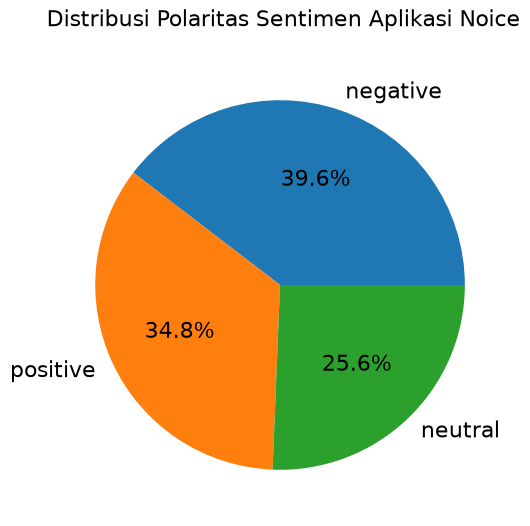

In [15]:
# Visualisasi distribusi polaritas sentimen
fig, ax = plt.subplots(figsize=(6, 6))
sizes = [count for count in df['polarity'].value_counts()]
labels = list(df['polarity'].value_counts().index)

# Pie chart
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%',  textprops={'fontsize': 16})
ax.set_title(' Distribusi Polaritas Sentimen Aplikasi Noice', fontsize=16, pad=20)
plt.show()

In [16]:
# DataFrame untuk ulasan dengan polaritas positive
pd.set_option('display.max_colwidth', 3000)

positive = df[df['polarity'] == 'positive']
positive = positive[['text_final', 'polarity_score', 'polarity','text_stopword']]
positive = positive.reset_index(drop=True)
positive.index += 1

In [17]:
# DataFrame untuk ulasan dengan polaritas negative
pd.set_option('display.max_colwidth', 3000)

negative = df[df['polarity'] == 'negative']
negative = negative[['text_final', 'polarity_score', 'polarity','text_stopword']]
negative = negative.reset_index(drop=True)
negative.index += 1

In [18]:
# DataFrame untuk ulasan dengan polaritas neutral
pd.set_option('display.max_colwidth', 3000)

neutral = df[df['polarity'] == 'neutral']
neutral = neutral[['text_final', 'polarity_score', 'polarity','text_stopword']]
neutral = neutral.reset_index(drop=True)
neutral.index += 1

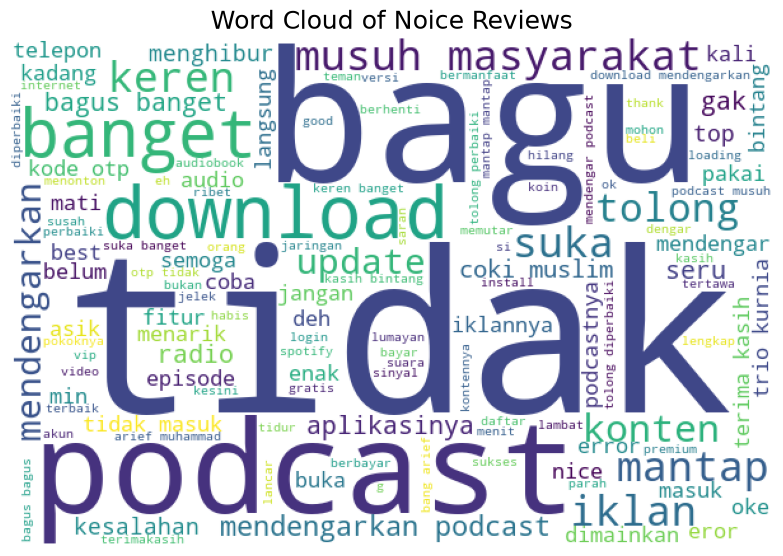

In [19]:
# Visualisasi Word Cloud dari data ulasan
list_words = ''
for tweet in df['text_stopword']:
    for word in tweet:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Noice Reviews', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

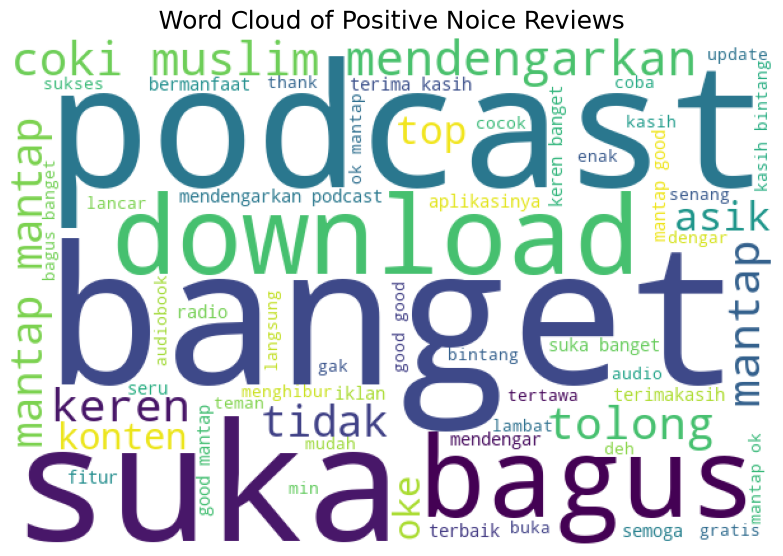

In [20]:
# Visualisasi Word Cloud dari data ulasan positive
list_words = ''
for tweet in positive['text_stopword']:
    for word in tweet:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Positive Noice Reviews', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

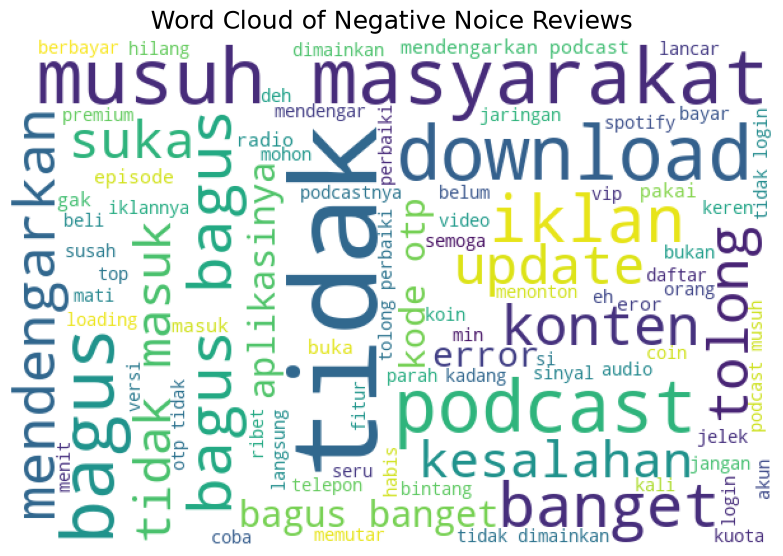

In [21]:
# Visualisasi Word Cloud dari data ulasan negative
list_words = ''
for tweet in negative['text_stopword']:
    for word in tweet:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Negative Noice Reviews', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

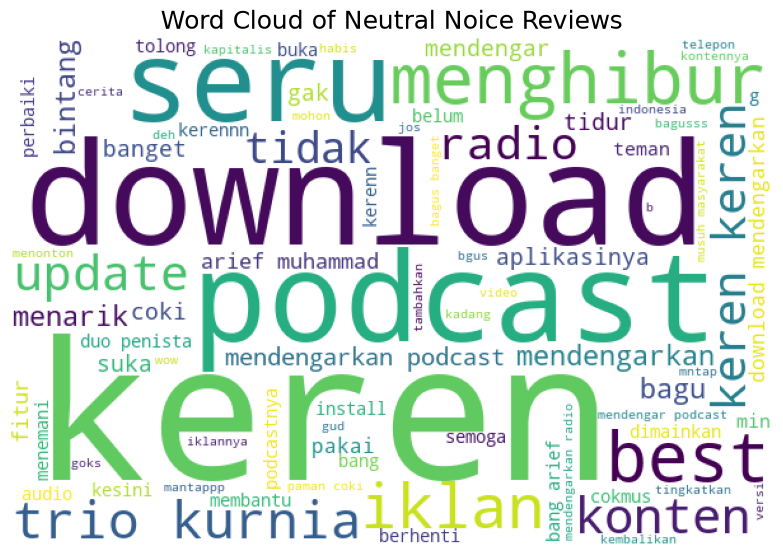

In [22]:
# Visualisasi Word Cloud dari data ulasan neutral
list_words = ''
for tweet in neutral['text_stopword']:
    for word in tweet:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Neutral Noice Reviews', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

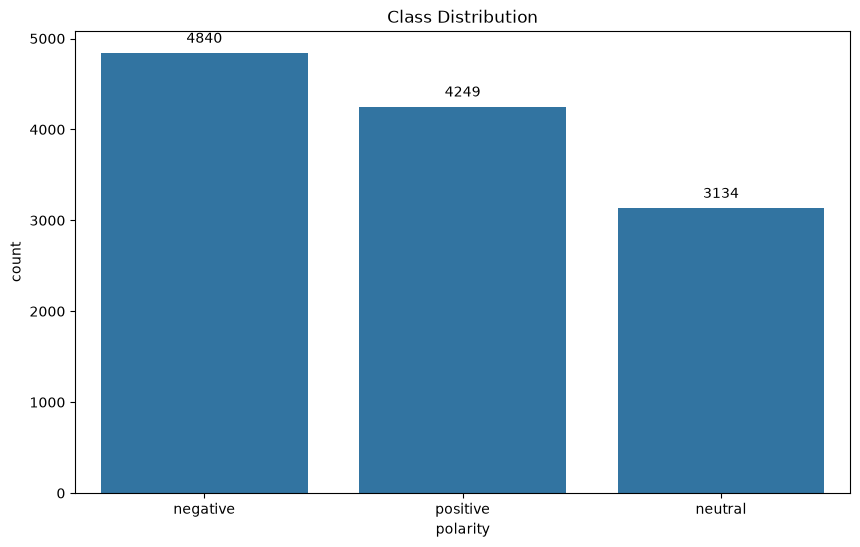

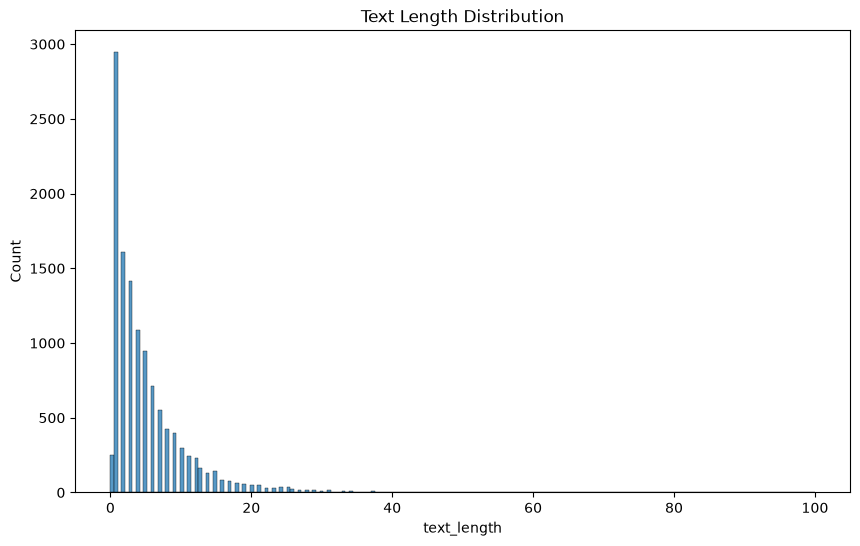

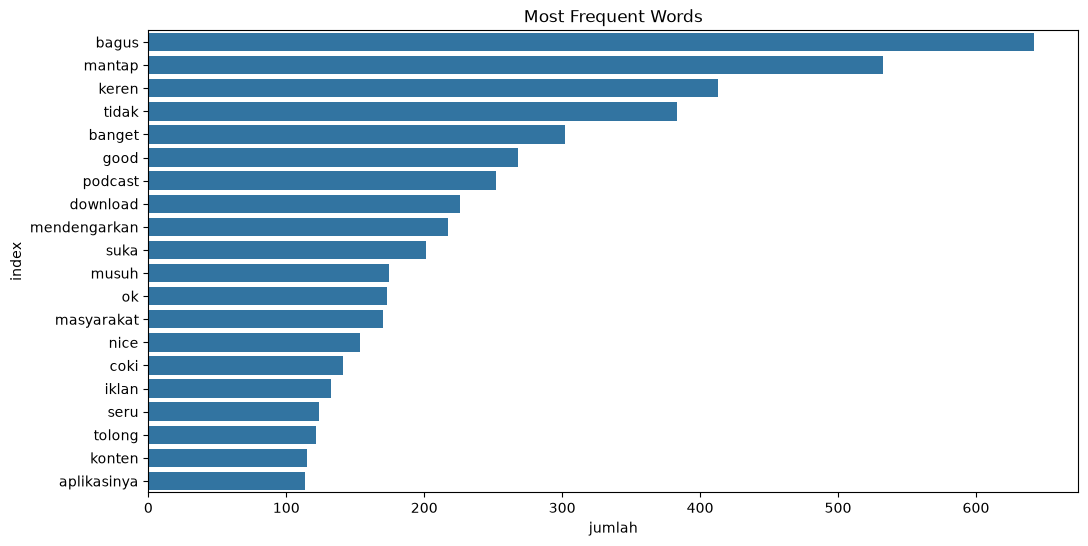

In [23]:
# Visualisasi distribusi kelas sentimen
plt.figure(figsize=(10, 6))
class_dist_plot = sns.countplot(x='polarity', data=df)
plt.title('Class Distribution')
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')
plt.show()

# Visualisasi distribusi panjang teks
plt.figure(figsize=(10, 6))
df['text_length'] = df['text_final'].apply(lambda x: len(x.split()))
sns.histplot(df['text_length'])
plt.title('Text Length Distribution')
plt.show()

# Visualisasi kata-kata yang paling sering muncul
plt.figure(figsize=(12, 6))
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['text_final'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

In [12]:
df_preprocessed = pd.DataFrame(df)
df_preprocessed.to_csv('noice_app_reviews_preprocessed.csv', index=False, encoding='utf-8')

In [14]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_final,polarity_score,polarity
0,43b531f3-1b08-4e19-b36b-662d88aa0b36,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasinya bagus, ada podcast favorit saya, d...",5,1,3.56,2026-06-24 22:36:41,3.56,aplikasinya bagus ada podcast favorit saya dan...,aplikasinya bagus ada podcast favorit saya dan...,aplikasinya bagus ada podcast favorit saya dan...,"[aplikasinya, bagus, ada, podcast, favorit, sa...","[aplikasinya, bagus, podcast, favorit, fitur, ...",aplikasinya bagus podcast favorit fitur downlo...,-2,negative
1,41c8cfd2-a8cc-48ed-992a-4db7627969ea,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"jujur sebenarnya bagus kok aplikasinya, kita m...",1,5,3.55.1,2026-05-09 01:27:24,3.55.1,jujur sebenarnya bagus kok aplikasinya kita me...,jujur sebenarnya bagus kok aplikasinya kita me...,jujur sebenarnya bagus kok aplikasinya kita me...,"[jujur, sebenarnya, bagus, kok, aplikasinya, k...","[jujur, bagus, aplikasinya, mendengarkan, podc...",jujur bagus aplikasinya mendengarkan podcast t...,1,positive
2,d1495c97-f24f-4d15-8c86-369c29b39256,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kecewa sm aplikasinya sudah download tp gak bi...,1,2,3.56,2026-06-05 19:52:56,3.56,kecewa sm aplikasinya sudah download tp gak bi...,kecewa sm aplikasinya sudah download tp gak bi...,kecewa sama aplikasinya sudah download tapi ti...,"[kecewa, sama, aplikasinya, sudah, download, t...","[kecewa, aplikasinya, download, tidak, buka, b...",kecewa aplikasinya download tidak buka berlang...,-19,negative
3,f6b7f1ad-46b6-4409-bdd3-6e86089bd4f2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aku naikkan bintangku karena konten Deddy Issu...,4,17,3.56,2026-05-28 10:19:53,3.56,Aku naikkan bintangku karena konten Deddy Issu...,aku naikkan bintangku karena konten deddy issu...,aku naikkan bintangku karena konten deddy issu...,"[aku, naikkan, bintangku, karena, konten, dedd...","[naikkan, bintangku, konten, deddy, issues, te...",naikkan bintangku konten deddy issues terjangk...,20,positive
4,5335c10b-85e5-4d71-ab56-2c66391a509f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sy download video tapi ternyata yg terdownload...,1,0,3.55.1,2026-06-08 18:50:43,3.55.1,sy download video tapi ternyata yg terdownload...,sy download video tapi ternyata yg terdownload...,saya download video tapi ternyata yang terdown...,"[saya, download, video, tapi, ternyata, yang, ...","[download, video, terdownload, audio, tolong, ...",download video terdownload audio tolong tombol...,-11,negative


## Feature Extraction

In [24]:
# Memisahkan data menjadi Fitur (X) dan Target (y)
X = df['text_final']
y = df['polarity']

# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=4000, min_df=17, max_df=0.8)
X_tfidf = tfidf.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
features_df

,ad,adain,admin,ah,akses,akun,ama,aman,an,anak,...,videonya,vip,wa,wajib,wawasan,web,wifi,wow,you,youtube
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.212481,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.345027,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12218,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12219,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12220,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12221,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Data Splitting

In [25]:
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

Training data shape: (8556, 466), Training labels shape: (8556,)
Test data shape: (3667, 466), Test labels shape: (3667,)


## Modelling

### Naive Bayes

In [26]:
from sklearn.naive_bayes import MultinomialNB

naive_bayes = MultinomialNB()
naive_bayes.fit(X_train.toarray(), y_train)

# Prediksi sentimen 
y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())

# Evaluasi akurasi
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)
print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.7289621318373072
Naive Bayes - accuracy_test: 0.7114807744750478


### Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()
random_forest.fit(X_train.toarray(), y_train)

# Prediksi sentimen
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

# Evaluasi akurasi
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)
print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9687938288920056
Random Forest - accuracy_test: 0.8590128170166349


### Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(class_weight='balanced', max_iter=1000)
logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.8895511921458625
Logistic Regression - accuracy_test: 0.8669211889828198


### Decision Tree

In [29]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train.toarray(), y_train)

# Prediksi sentimen
y_pred_train_dt = decision_tree.predict(X_train.toarray())
y_pred_test_dt = decision_tree.predict(X_test.toarray())

# Evaluasi akurasi
accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)
print('Decision Tree - accuracy_train:', accuracy_train_dt)
print('Decision Tree - accuracy_test:', accuracy_test_dt)

Decision Tree - accuracy_train: 0.9687938288920056
Decision Tree - accuracy_test: 0.829560949004636


### Support Vector Machine

In [30]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train.toarray(), y_train)

# Prediksi sentimen
y_pred_train_svm = svm.predict(X_train.toarray())
y_pred_test_svm = svm.predict(X_test.toarray())

# Evaluasi akurasi
accuracy_train_svm = accuracy_score(y_pred_train_svm, y_train)
accuracy_test_svm = accuracy_score(y_pred_test_svm, y_test)
print('SVM - accuracy_train:', accuracy_train_svm)
print('SVM - accuracy_test:', accuracy_test_svm)

SVM - accuracy_train: 0.9430808789153811
SVM - accuracy_test: 0.8680119989091901


In [31]:
# Rangkuman hasil akurasi test dari semua model
results_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'Random Forest', 'Logistic Regression', 'Decision Tree', 'Support Vector Machine'],
    'Accuracy Train': [accuracy_train_nb, accuracy_train_rf, accuracy_train_lr, accuracy_train_dt, accuracy_train_svm],
    'Accuracy Test': [accuracy_test_nb, accuracy_test_rf, accuracy_test_lr, accuracy_test_dt, accuracy_test_svm]
})

accuracy_test_only = results_df[['Model', 'Accuracy Test']]
print(accuracy_test_only)

                    Model  Accuracy Test
0             Naive Bayes       0.711481
1           Random Forest       0.859013
2     Logistic Regression       0.866921
3           Decision Tree       0.829561
4  Support Vector Machine       0.868012


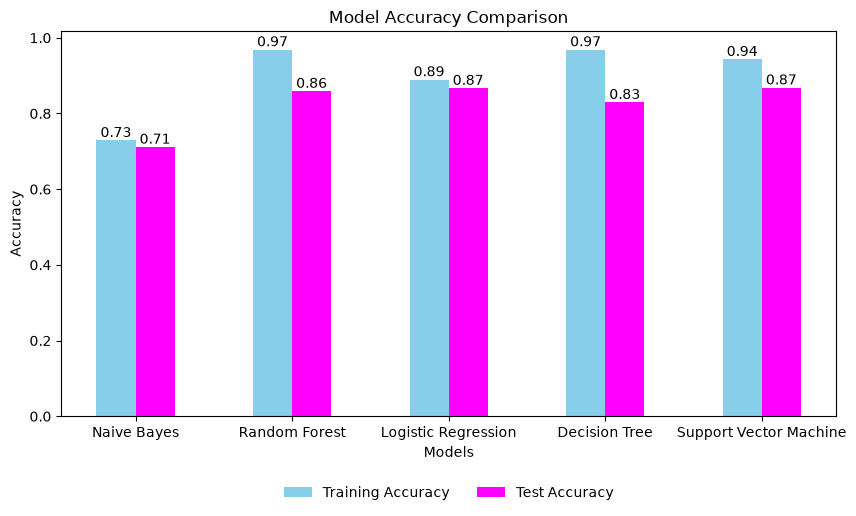

In [32]:
# Visualisasi perbandingan akurasi model
plt.figure(figsize=(10, 5))
bar_width = 0.25
index = np.arange(len(results_df['Model']))

train_bars = plt.bar(index, results_df['Accuracy Train'], bar_width, label='Training Accuracy', color='skyblue')
test_bars = plt.bar(index + bar_width, results_df['Accuracy Test'], bar_width, label='Test Accuracy', color='magenta')

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(index + bar_width / 2, results_df['Model'])
plt.legend(loc='center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)

for bar in train_bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')

for bar in test_bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')

plt.show()

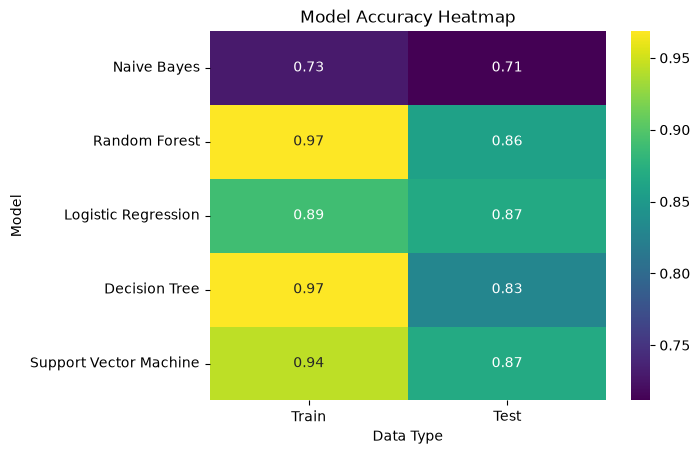

In [33]:
# Visualisasi heatmap akurasi model
sns.heatmap(results_df[['Accuracy Train', 'Accuracy Test']], annot=True, cmap='viridis', xticklabels=['Train', 'Test'], yticklabels=results_df['Model'])
plt.title('Model Accuracy Heatmap')
plt.xlabel('Data Type')
plt.ylabel('Model')
plt.show()

## Test New Sentece

In [34]:
# Tes kalimat baru
sentence = "Sekarang podcast musuh masyarakat harus berbayar, tidak seperti dulu"

# Preprocessing
sentence_cleaned = cleaningText(sentence)
sentence_casefolded = casefoldingText(sentence_cleaned)
sentence_slangfixed = fix_slangwords(sentence_casefolded)
sentence_tokenized = tokenizingText(sentence_slangfixed)
sentence_filtered = filteringText(sentence_tokenized)
sentence_final = toSentence(sentence_filtered)
X_sentence = tfidf.transform([sentence_final])

# Prediksi sentimen
sentiment = logistic_regression.predict(X_sentence)
if sentiment[0] == 'positive':
    print("The sentiment is POSITIVE.")
elif sentiment[0] == 'negative':
    print("The sentiment is NEGATIVE.")
else:
    print("The sentiment is NEUTRAL.")

The sentiment is NEGATIVE.


## Saving Model

In [35]:
# Saving model & vectorizer using joblib
joblib.dump(logistic_regression, 'logistic_regression.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
print("Model and vectorizer saved")

Model and vectorizer saved
